In [2]:
import pandas as pd
df = pd.read_csv('Social_media_impact_on_life.csv')

In [3]:
df.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,232,21,Male,Undergraduate,Other,4.0,Facebook,No,6.7,6.8,Neutral
1,564,23,Female,Undergraduate,Other,1.6,LinkedIn,No,8.6,7.6,Positive
2,788,22,Male,Graduate,Canada,4.6,Instagram,No,6.7,7.0,Neutral
3,686,18,Male,Undergraduate,Other,7.0,Snapchat,Yes,5.4,5.3,Negative
4,608,24,Female,High School,Other,7.5,Facebook,Yes,5.0,4.4,Negative


In [4]:
df.tail()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
1700,701,20,Female,Undergraduate,Italy,4.7,TikTok,No,7.2,7.0,Positive
1701,702,23,Male,Graduate,Russia,6.8,Instagram,Yes,5.9,4.0,Negative
1702,703,21,Female,Undergraduate,China,5.6,WeChat,Yes,6.7,6.0,Negative
1703,704,24,Male,Graduate,Japan,4.3,Twitter,No,7.5,8.0,Positive
1704,705,19,Female,Undergraduate,Poland,6.2,Facebook,Yes,6.3,5.0,Negative


In [5]:
df.describe()

,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,1705.000000,1705.000000,1705.000000,1705.000000,1705.000000
mean,439.510264,20.848094,5.103636,6.598710,6.215132
std,267.058174,1.758557,1.677341,1.207045,1.282678
min,1.000000,18.000000,1.500000,3.800000,4.000000
25%,214.000000,19.000000,3.800000,5.600000,5.000000
50%,427.000000,21.000000,5.100000,6.600000,6.000000
75%,640.000000,22.000000,6.300000,7.500000,7.000000
max,1000.000000,24.000000,8.500000,9.600000,9.000000


In [7]:
df.isnull().sum()

Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Overall_Impact                  0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1705 entries, 0 to 1704
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    1705 non-null   int64  
 1   Age                           1705 non-null   int64  
 2   Gender                        1705 non-null   object 
 3   Academic_Level                1705 non-null   object 
 4   Country                       1705 non-null   object 
 5   Avg_Daily_Usage_Hours         1705 non-null   float64
 6   Most_Used_Platform            1705 non-null   object 
 7   Affects_Academic_Performance  1705 non-null   object 
 8   Sleep_Hours_Per_Night         1705 non-null   float64
 9   Mental_Health_Score           1705 non-null   float64
 10  Overall_Impact                1705 non-null   object 
dtypes: float64(3), int64(2), object(6)
memory usage: 146.7+ KB


In [9]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

In [10]:
X = df.drop("Overall_Impact",axis=1)
y = df["Overall_Impact"]

In [11]:
y = LabelEncoder().fit_transform(y)

In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [18]:
rf = RandomForestClassifier()
rf.fit(X_train,y_train)

RandomForestClassifier()

In [19]:
from sklearn.metrics import accuracy_score,classification_report
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9032258064516129
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       197
           1       0.79      0.53      0.64        51
           2       0.94      0.98      0.96        93

    accuracy                           0.90       341
   macro avg       0.88      0.82      0.84       341
weighted avg       0.90      0.90      0.90       341



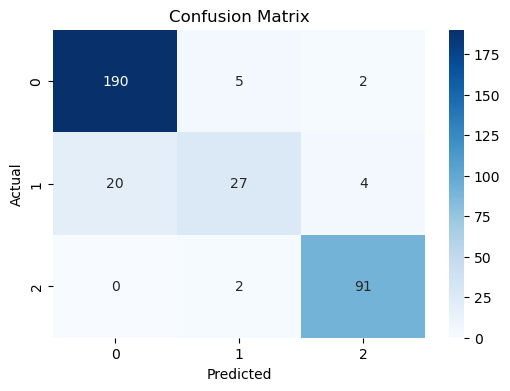

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()